# Import Library

In [19]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import pillow_heif
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import legacy as legacy_optimizers
from tensorflow.keras import mixed_precision

In [2]:
import sys

strategy = tf.distribute.get_strategy()
print("Number of replicas : ", strategy.num_replicas_in_sync)
print('TensorFlow : ', tf.__version__)
print('Python     : ', sys.version.split()[0])

num_gpus = len(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available : ", num_gpus)
print("Using device       : ", tf.test.gpu_device_name())

Number of replicas :  1
TensorFlow :  2.10.1
Python     :  3.10.18
Num GPUs Available :  1
Using device       :  /device:GPU:0


In [3]:
if num_gpus > 0:
    print("✅ GPU is available")
else:
    print("❌ GPU is unavailable")

✅ GPU is available


# Load Dataset

In [4]:
day = r"C:\DATA SEKUNDER\Day"
night = r"C:\DATA SEKUNDER\Night"

day_Resized = r"C:\DATA SEKUNDER\Resized\Day"
night_Resized = r"C:\DATA SEKUNDER\Resized\Night"

os.makedirs(day_Resized, exist_ok=True)
os.makedirs(night_Resized, exist_ok=True)

In [5]:
mixed_precision.set_global_policy('float32')
print("Precision Policy:", mixed_precision.global_policy())

Precision Policy: <Policy "float32">


## Image Resize

In [ ]:
def resize_images(input_dir, output_dir, size=(256, 256)):
    for f in os.listdir(input_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(input_dir, f)
            try:
                img = Image.open(path).convert("RGB")
                img = img.resize(size)
                img.save(os.path.join(output_dir, f))
            except Exception as e:
                print(f"Gagal resize {f}: {e}")

resize_images(day, day_Resized)
resize_images(night, night_Resized)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
strategy = tf.distribute.MirroredStrategy()
print("GPU Devices:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
GPU Devices: 1


In [46]:
day_images = tf.io.gfile.glob(os.path.join(day_Resized, "*.jpg"))
night_images = tf.io.gfile.glob(os.path.join(night_Resized, "*.jpg"))

print(f"Total Day : {len(day_images)}")
print(f"Total Night : {len(night_images)}")

Total Day : 9000
Total Night : 6000


In [25]:
def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [256,256])
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1.0   
    return image

BATCH_SIZE = 2
day_ds = tf.data.Dataset.from_tensor_slices(day_images).map(preprocess_image, num_parallel_calls=AUTOTUNE)
night_ds = tf.data.Dataset.from_tensor_slices(night_images).map(preprocess_image, num_parallel_calls=AUTOTUNE)
day_ds = day_ds.shuffle(1000).batch(1).prefetch(AUTOTUNE)
night_ds = night_ds.shuffle(1000).batch(1).prefetch(AUTOTUNE)

In [26]:
class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.scale = self.add_weight(name="scale", shape=(channels,),initializer="ones", trainable=True, dtype=tf.float32)
        self.offset = self.add_weight(name="offset", shape=(channels,),initializer="zeros", trainable=True, dtype=tf.float32)

    def call(self, x):
        x32 = tf.cast(x, tf.float32)
        mean, var = tf.nn.moments(x32, axes=[1, 2], keepdims=True)
        inv = tf.math.rsqrt(var + self.epsilon)
        normalized = (x32 - mean) * inv
        out = self.scale * normalized + self.offset
        return tf.cast(out, x.dtype)

In [27]:
def Generator(input_shape=(256, 256, 3), ngf=64, n_down=4):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    skips = []

    # Encoder
    for i in range(n_down):
        filters = ngf * (2 ** i)
        x = layers.ZeroPadding2D(1)(x)  
        x = layers.Conv2D(filters, 4, strides=2, padding='valid',use_bias=False, kernel_initializer='he_normal')(x)
        if i != 0:
            x = InstanceNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        skips.append(x)

    # Bottleneck
    bottleneck_filters = ngf * (2 ** n_down)
    x = layers.Conv2D(bottleneck_filters, 4, strides=1, padding='same',use_bias=False, kernel_initializer='he_normal')(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder
    for i in reversed(range(n_down)):
        skip = skips[i]
        filters = ngf * (2 ** i)
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding='same',use_bias=False, kernel_initializer='he_normal')(x)
        x = InstanceNormalization()(x)
        if i < 2:
            x = layers.Dropout(0.5)(x)
        x = layers.ReLU()(x)
        x = layers.Concatenate()([x, skip])

    out = layers.Conv2DTranspose(3, 4, strides=1, padding='same',activation='tanh', kernel_initializer='glorot_uniform')(x)

    return Model(inputs=inputs, outputs=out, name="U_Net_Generator")

In [28]:
def Discriminator(input_shape=(256, 256, 3), ndf=64, n_layers=3):
    inp = layers.Input(shape=input_shape)
    x = inp

    # First layer: no normalization
    x = layers.Conv2D(ndf, 4, strides=2, padding='same',kernel_initializer='he_normal')(x)
    x = layers.LeakyReLU(0.2)(x)

    nf_mult = 1
    for n in range(1, n_layers):
        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n, 8)
        x = layers.Conv2D(ndf * nf_mult, 4,strides=2 if n < n_layers - 1 else 1,padding='same', use_bias=False,kernel_initializer='he_normal')(x)
        x = InstanceNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1, 4, strides=1, padding='same',kernel_initializer='glorot_uniform')(x)

    return Model(inputs=inp, outputs=out, name="PatchGAN_Discriminator")

In [29]:
mse = tf.keras.losses.MeanSquaredError()

def discriminator_loss(real, fake):
    real_loss = mse(tf.ones_like(real), real)
    fake_loss = mse(tf.zeros_like(fake), fake)
    return 0.5 * (real_loss + fake_loss)

def generator_loss(fake):
    return mse(tf.ones_like(fake), fake)

LAMBDA_CYCLE = 25.0      
LAMBDA_IDENTITY = 4.0    

def cycle_loss(real, cycled):
    real = tf.cast(real, tf.float32)
    cycled = tf.cast(cycled, tf.float32)
    return LAMBDA_CYCLE * tf.reduce_mean(tf.abs(real - cycled))

def identity_loss(real, same):
    real = tf.cast(real, tf.float32)
    same = tf.cast(same, tf.float32)
    return LAMBDA_IDENTITY * 0.5 * tf.reduce_mean(tf.abs(real - same))

In [30]:
day2night_gen = Generator()
night2day_gen = Generator()
day_disc = Discriminator()
night_disc = Discriminator()

initial_lr = 2e-4
steps_per_epoch = max(1, min(len(day_images), len(night_images)) // BATCH_SIZE)
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[50 * steps_per_epoch, 75 * steps_per_epoch],
    values=[initial_lr, initial_lr * 0.1, initial_lr * 0.01]
)

gen_opt = legacy_optimizers.Adam(learning_rate=lr_schedule, beta_1=0.5)
disc_opt = legacy_optimizers.Adam(learning_rate=lr_schedule, beta_1=0.5)

In [33]:
@tf.function
def train_step(real_day, real_night):
    with tf.GradientTape() as tape:
        # Forward pass: generator
        fake_night = day2night_gen(real_day, training=True)
        fake_day = night2day_gen(real_night, training=True)

        # Cycle consistency
        cycled_day = night2day_gen(fake_night, training=True)
        cycled_night = day2night_gen(fake_day, training=True)

        # Identity mapping
        same_day = night2day_gen(real_day, training=True)
        same_night = day2night_gen(real_night, training=True)

        # Discriminator predictions
        D_real_day = day_disc(real_day, training=True)
        D_fake_day = day_disc(fake_day, training=True)
        D_real_night = night_disc(real_night, training=True)
        D_fake_night = night_disc(fake_night, training=True)

        # Generator losses
        G_day_loss = generator_loss(D_fake_day)
        G_night_loss = generator_loss(D_fake_night)
        cyc_loss = cycle_loss(real_day, cycled_day) + cycle_loss(real_night, cycled_night)
        id_loss = identity_loss(real_day, same_day) + identity_loss(real_night, same_night)

        total_day2night_loss = G_night_loss + cyc_loss + id_loss
        total_night2day_loss = G_day_loss + cyc_loss + id_loss

        # Discriminator losses
        D_day_loss = discriminator_loss(D_real_day, D_fake_day)
        D_night_loss = discriminator_loss(D_real_night, D_fake_night)

        # Total losses
        total_gen_loss = total_day2night_loss + total_night2day_loss
        total_disc_loss = D_day_loss + D_night_loss

    # Combine gradients
    gen_vars = day2night_gen.trainable_variables + night2day_gen.trainable_variables
    disc_vars = day_disc.trainable_variables + night_disc.trainable_variables

    gen_grads, disc_grads = tape.gradient(
        [total_gen_loss, total_disc_loss],
        [gen_vars, disc_vars]
    )

    gen_opt.apply_gradients(zip(gen_grads, gen_vars))
    disc_opt.apply_gradients(zip(disc_grads, disc_vars))

    return total_day2night_loss, total_night2day_loss, D_day_loss, D_night_loss

In [34]:
history = {'day2night_gen': [], 'night2day_gen': [], 'day_disc': [], 'night_disc': []}
EPOCHS = 15

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    d2n_gen, n2d_gen, d_disc, n_disc, n_batches = 0, 0, 0, 0, 0

    for real_day, real_night in tf.data.Dataset.zip((day_ds, night_ds)):
        try:
            d2n_gen_loss, n2d_gen_loss, d_disc_loss, n_disc_loss = train_step(real_day, real_night)
        except tf.errors.ResourceExhaustedError:
            print("⚠️ Skipping batch (OOM).")
            tf.keras.backend.clear_session()
            continue

        d2n_gen += d2n_gen_loss.numpy()
        n2d_gen += n2d_gen_loss.numpy()
        d_disc += d_disc_loss.numpy()
        n_disc += n_disc_loss.numpy()
        n_batches += 1

    history['day2night_gen'].append(d2n_gen/n_batches)
    history['night2day_gen'].append(n2d_gen/n_batches)
    history['day_disc'].append(d_disc/n_batches)
    history['night_disc'].append(n_disc/n_batches)

    print(f"Day→Night Gen: {d2n_gen/n_batches:.4f}, Night→Day Gen: {n2d_gen/n_batches:.4f}, "
          f"Day Disc: {d_disc/n_batches:.4f}, Night Disc: {n_disc/n_batches:.4f}")


Epoch 1/15
Day→Night Gen: 3.9089, Night→Day Gen: 3.9016, Day Disc: 0.2539, Night Disc: 0.2446

Epoch 2/15
Day→Night Gen: 2.8086, Night→Day Gen: 2.8058, Day Disc: 0.2343, Night Disc: 0.2286

Epoch 3/15
Day→Night Gen: 2.5503, Night→Day Gen: 2.5487, Day Disc: 0.2307, Night Disc: 0.2270

Epoch 4/15
Day→Night Gen: 2.4053, Night→Day Gen: 2.4042, Day Disc: 0.2289, Night Disc: 0.2264

Epoch 5/15
Day→Night Gen: 2.3051, Night→Day Gen: 2.3040, Day Disc: 0.2282, Night Disc: 0.2254

Epoch 6/15
Day→Night Gen: 2.2327, Night→Day Gen: 2.2315, Day Disc: 0.2276, Night Disc: 0.2249

Epoch 7/15
Day→Night Gen: 2.1761, Night→Day Gen: 2.1752, Day Disc: 0.2268, Night Disc: 0.2246

Epoch 8/15
Day→Night Gen: 2.1306, Night→Day Gen: 2.1295, Day Disc: 0.2268, Night Disc: 0.2246

Epoch 9/15
Day→Night Gen: 2.0892, Night→Day Gen: 2.0885, Day Disc: 0.2259, Night Disc: 0.2239

Epoch 10/15
Day→Night Gen: 2.0352, Night→Day Gen: 2.0345, Day Disc: 0.2257, Night Disc: 0.2240

Epoch 11/15
Day→Night Gen: 1.9829, Night→Day Gen

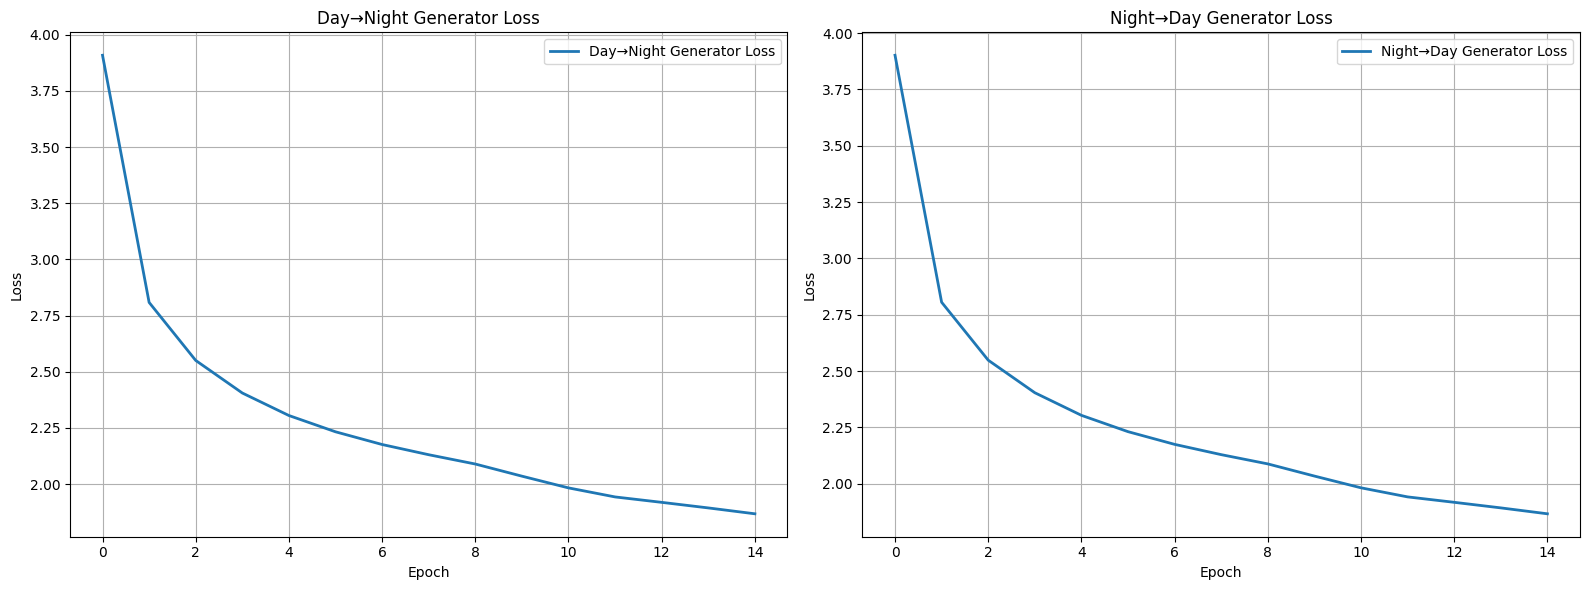

In [35]:
def plot_generator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['day2night_gen']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['day2night_gen'], label='Day→Night Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day→Night Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['night2day_gen'], label='Night→Day Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night→Day Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_generator_loss(history)

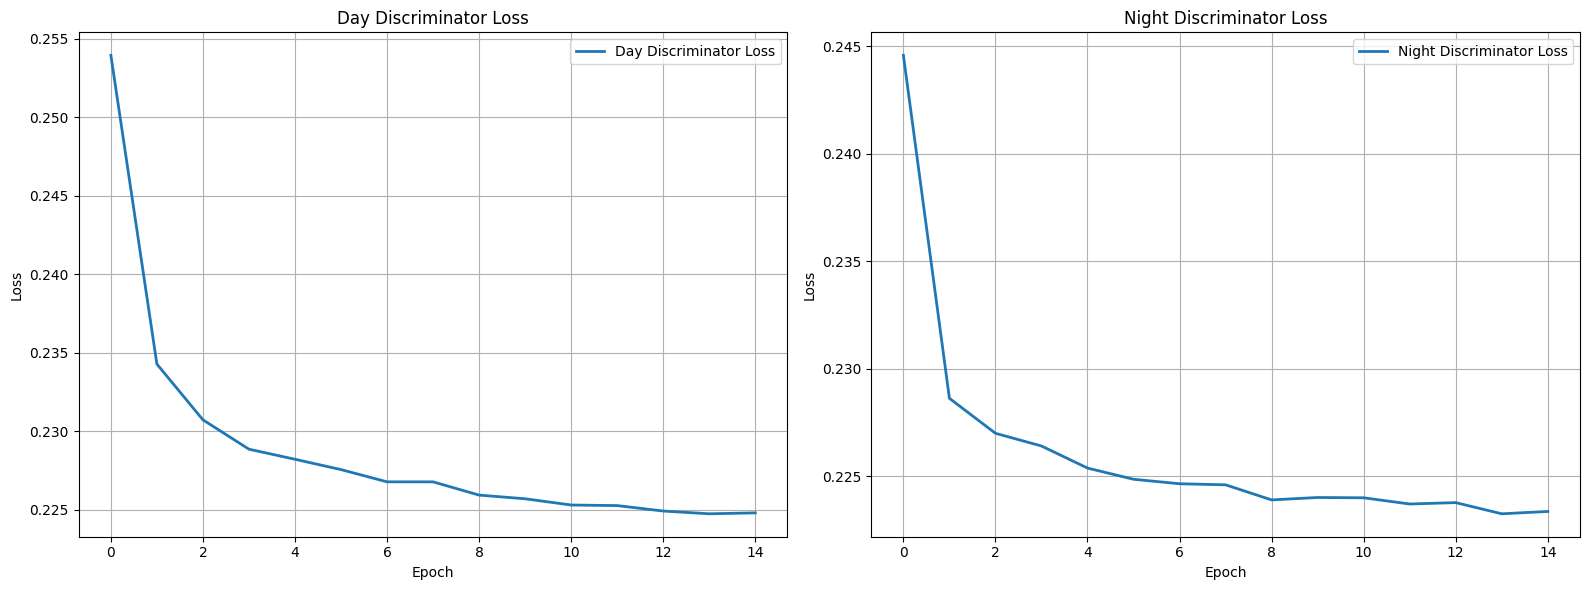

In [36]:
def plot_discriminator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['day_disc']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['day_disc'], label='Day Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['night_disc'], label='Night Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_discriminator_loss(history)

In [42]:
def display_generated_day_images(night2day_gen, dataset, num_images=5, start_from=0):
    """
    Menampilkan hasil konversi dari night → generated day
    beserta SSIM antara real night dan hasil generated day.
    """
    plt.figure(figsize=(20, 8))
    ssim_scores = []

    # Ambil beberapa batch dari dataset
    selected_imgs = dataset.skip(start_from).take(num_images)

    for i, real_img in enumerate(selected_imgs):
        # Jika dataset sudah batched, ambil 1 gambar saja
        if len(real_img.shape) == 4:
            real_img = real_img[0]
        real_img = tf.expand_dims(real_img, axis=0)  # (1, 256, 256, 3)

        # Generate hasil konversi night → day
        generated_day = night2day_gen(real_img, training=False)

        # Rescale ke [0,1]
        def rescale(x): return (x[0] * 0.5 + 0.5).numpy().clip(0, 1)
        real_img_rescaled = rescale(real_img)
        generated_day_rescaled = rescale(generated_day)

        # SSIM antara real dan hasil generator
        ssim_score = tf.image.ssim(real_img_rescaled, generated_day_rescaled, max_val=1.0).numpy()
        ssim_scores.append(ssim_score * 100)

        # Plot dua kolom: real dan generated
        plt.subplot(2, num_images, i + 1)
        plt.imshow(real_img_rescaled)
        plt.title("Original Night", fontsize=14)
        plt.axis("off")

        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(generated_day_rescaled)
        plt.title(f"Generated Day\nSSIM: {ssim_score*100:.2f}%", fontsize=13)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return ssim_scores

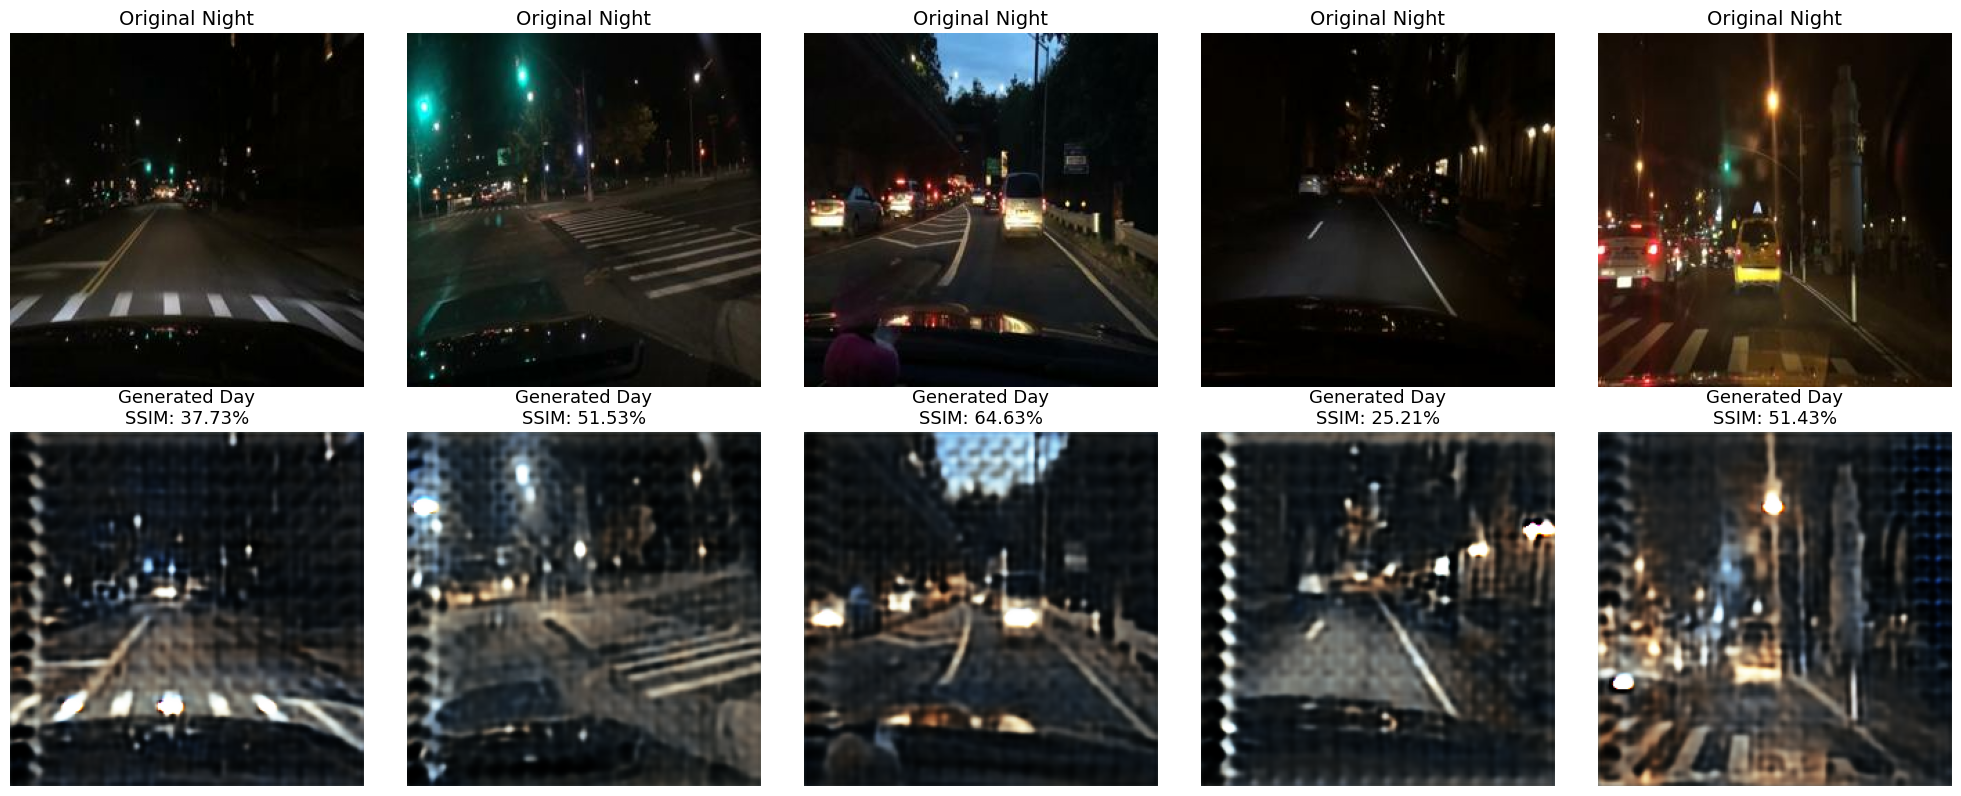

In [43]:
ssim_night2day = display_generated_day_images(night2day_gen, night_ds, num_images=5)

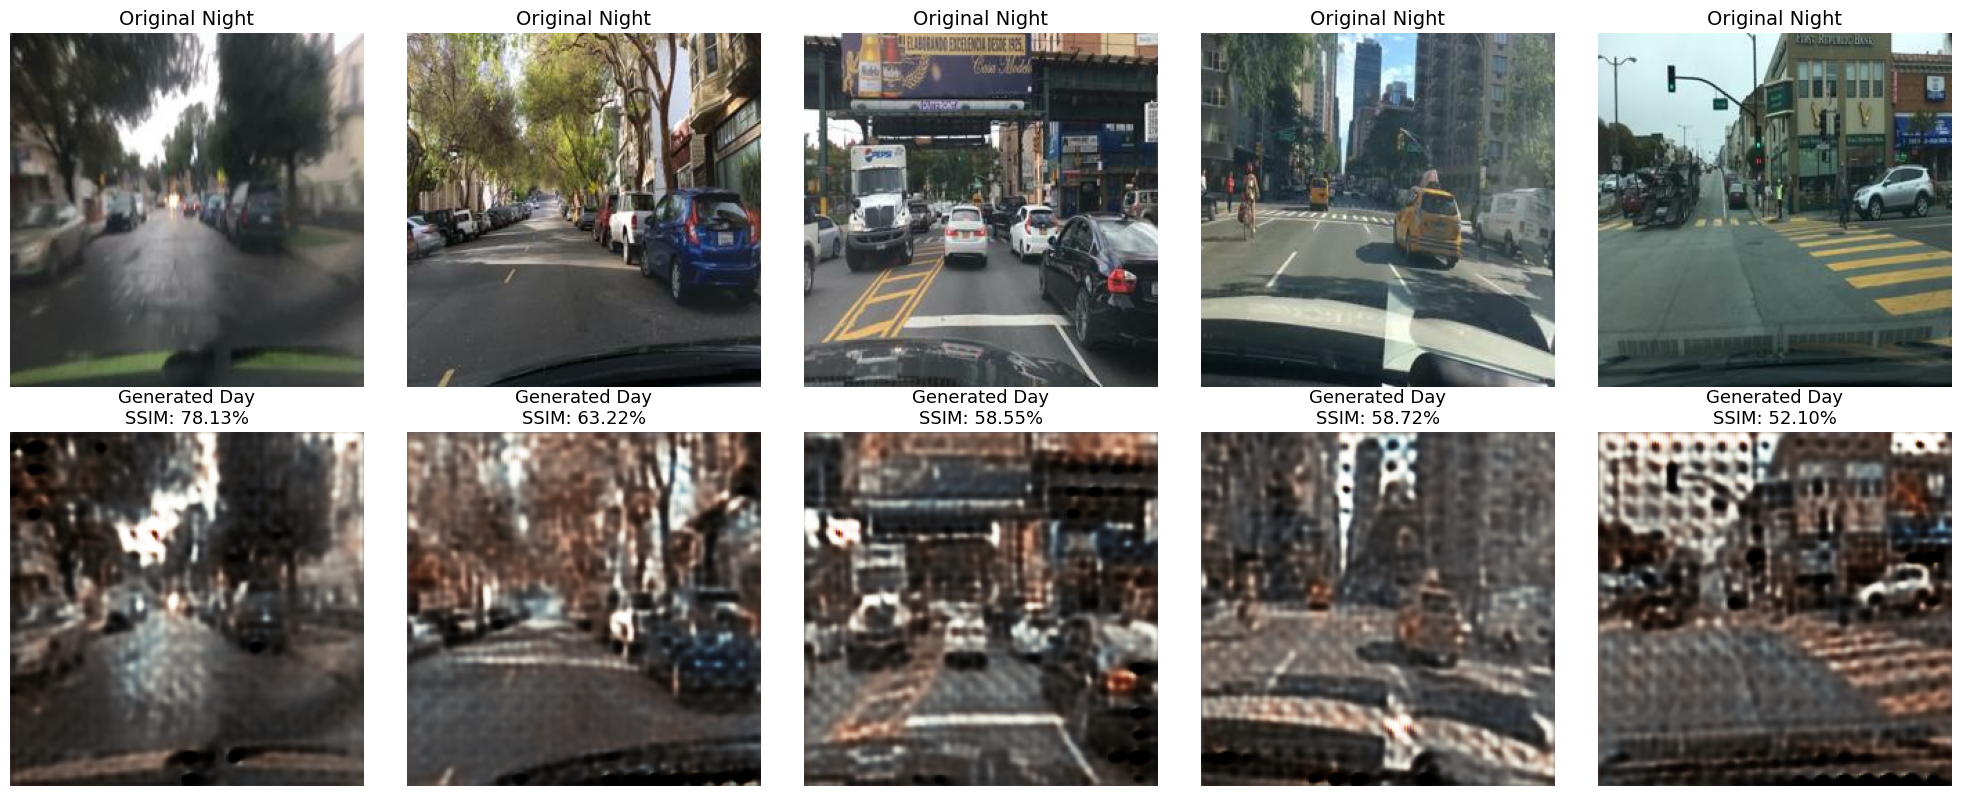

In [44]:
ssim_day2night = display_generated_day_images(day2night_gen, day_ds, num_images=5)